In [5]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from Preprocess import preprocess_data

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = preprocess_data(filtered_time, data_orig)

0        True
1        True
2        True
3        True
4        True
        ...  
5145     True
5146     True
5147     True
5148     True
5149    False
Name: time_to_next_ev_hr, Length: 5150, dtype: bool
(5002, 3)
(4941, 8)
(5150, 8)


In [7]:
# Predicting the typical time gap between each event
median_ttns = y_train.median() #Finding the typical inter-event time gap
y_predicted_median =[median_ttns]*len(y_test) #Median predicition for each event in the list
MAE_median = mean_absolute_error(y_test, y_predicted_median) #Comparing how the median prediction comapares to the ML methods using mean absolute error
Median_Error = MAE_median 
y_test_secs_median = y_test #Taking it out of log scale
y_pred_secs_median = [y for y in y_predicted_median]

absolute_error_secs_median = np.abs(y_pred_secs_median - y_test_secs_median)
print("MAE for Median:", np.mean(absolute_error_secs_median))

# Presistence baseline; assuming the TTNS is the same as the previous one
# Using an array where the first column is the TTNS from the previous event and the second column is the actual TTNS for the that event
y_test_array = y_test.values
y_predicted_presist = y_test_array[:-1]
y_actual = y_test_array[1:]

MAE_presist = mean_absolute_error(y_actual, y_predicted_presist)
Presist_Error = MAE_presist
print("MAE for Presistent:", Presist_Error)


Median_RMSE = root_mean_squared_error(y_test, y_predicted_median)
Median_Error = Median_RMSE
print("Median RMSE Error:", Median_Error)

Presist_RMSE = root_mean_squared_error(y_test[1:], y_predicted_presist)
Presist_Error = Presist_RMSE
print("Presist RMSE Error:", Presist_Error)

MAE for Median: 22532.96604527297
MAE for Presistent: 20556.26
Median RMSE Error: 26863.375376328284
Presist RMSE Error: 26471.26873989987


Sample0: True = 88080.00s, Predicted = 51622.50s, Error=36457.50s
Sample1: True = 78075.00s, Predicted = 51622.50s, Error=26452.50s
Sample2: True = 49485.00s, Predicted = 51622.50s, Error=2137.50s
Sample3: True = 53820.00s, Predicted = 51622.50s, Error=2197.50s
Sample4: True = 75000.00s, Predicted = 51622.50s, Error=23377.50s
Sample5: True = 43140.00s, Predicted = 51622.50s, Error=8482.50s
Sample6: True = 47130.00s, Predicted = 51622.50s, Error=4492.50s
Sample7: True = 87630.00s, Predicted = 51622.50s, Error=36007.50s
Sample8: True = 87960.00s, Predicted = 51622.50s, Error=36337.50s
Sample9: True = 39150.00s, Predicted = 51622.50s, Error=12472.50s
Sample10: True = 53550.00s, Predicted = 51622.50s, Error=1927.50s
Sample11: True = 83610.00s, Predicted = 51622.50s, Error=31987.50s
Sample12: True = 93015.00s, Predicted = 51622.50s, Error=41392.50s
Sample13: True = 73710.00s, Predicted = 51622.50s, Error=22087.50s
Sample14: True = 55650.00s, Predicted = 51622.50s, Error=4027.50s
Sample15: T

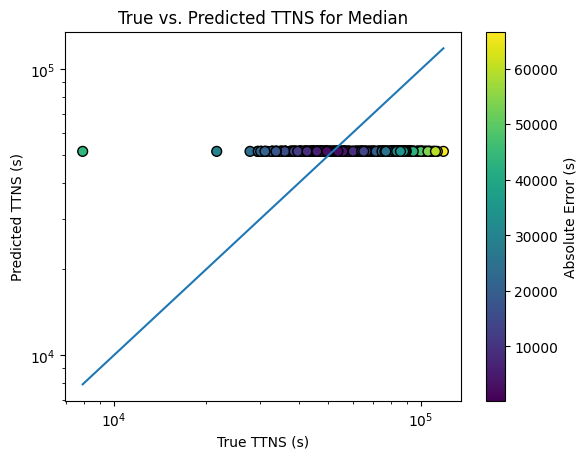

Sample0: True = 78075.00s, Predicted = 88080.00s, Error=10005.00s
Sample1: True = 49485.00s, Predicted = 78075.00s, Error=28590.00s
Sample2: True = 53820.00s, Predicted = 49485.00s, Error=4335.00s
Sample3: True = 75000.00s, Predicted = 53820.00s, Error=21180.00s
Sample4: True = 43140.00s, Predicted = 75000.00s, Error=31860.00s
Sample5: True = 47130.00s, Predicted = 43140.00s, Error=3990.00s
Sample6: True = 87630.00s, Predicted = 47130.00s, Error=40500.00s
Sample7: True = 87960.00s, Predicted = 87630.00s, Error=330.00s
Sample8: True = 39150.00s, Predicted = 87960.00s, Error=48810.00s
Sample9: True = 53550.00s, Predicted = 39150.00s, Error=14400.00s
Sample10: True = 83610.00s, Predicted = 53550.00s, Error=30060.00s
Sample11: True = 93015.00s, Predicted = 83610.00s, Error=9405.00s
Sample12: True = 73710.00s, Predicted = 93015.00s, Error=19305.00s
Sample13: True = 55650.00s, Predicted = 73710.00s, Error=18060.00s
Sample14: True = 38625.00s, Predicted = 55650.00s, Error=17025.00s
Sample15: 

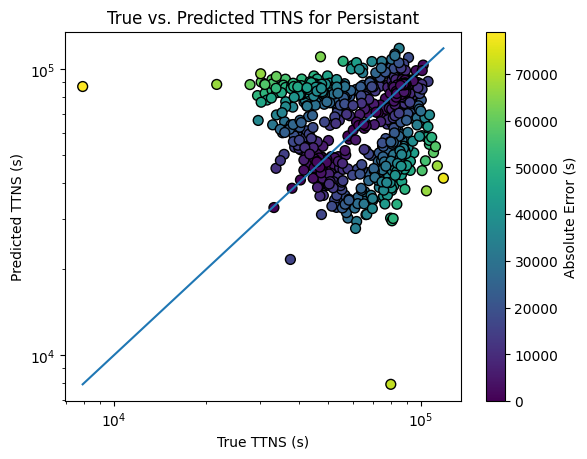

In [8]:
# Baseline Analysis:Median

y_test_secs = y_test #Taking it out of log scale
y_pred_secs = y_predicted_median

absolute_error_secs = np.abs(y_pred_secs - y_test_secs)

for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, y_pred_secs, absolute_error_secs)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, y_pred_secs, c=absolute_error_secs, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for Median")
plt.xscale('log')
plt.yscale('log')
plt.show()

#Persistnat 
y_test_secs = y_test[1:] #Taking it out of log scale
y_pred_secs = y_predicted_presist

absolute_error_secs = np.abs(y_pred_secs - y_test_secs)

for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, y_pred_secs, absolute_error_secs)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, y_pred_secs, c=absolute_error_secs, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for Persistant")
plt.xscale('log')
plt.yscale('log')
plt.show()